In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [45]:
df_ci = pd.read_csv('census-income.csv')

In [3]:
def func_find(i):
  print(type(i), i)
  print(i=='?')
  return i == '?'

df_ci[df_ci.apply(func_find).any(axis=1)]

<class 'pandas.core.series.Series'> 0        39
1        50
2        38
3        53
4        28
         ..
32556    27
32557    40
32558    58
32559    22
32560    52
Name: age, Length: 32561, dtype: int64
0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557    False
32558    False
32559    False
32560    False
Name: age, Length: 32561, dtype: bool
<class 'pandas.core.series.Series'> 0               State-gov
1        Self-emp-not-inc
2                 Private
3                 Private
4                 Private
               ...       
32556             Private
32557             Private
32558             Private
32559             Private
32560        Self-emp-inc
Name: workclass, Length: 32561, dtype: object
0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557    False
32558    False
32559    False
32560    False
Name: workclass, Length: 32561, dtype: bool
<class 'panda

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,?,>50K
27,54,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,?,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,?,<=50K
61,32,?,293936,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32530,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32531,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32539,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32541,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [4]:
df_ci = df_ci.replace('?', np.nan)

In [5]:
df_ci[(df_ci['occupation'] == 'Tech-support') & (df_ci['annual_income'] == '>50K')].shape

(283, 15)

In [6]:
df_ci.apply(lambda i: i == '?').sum().sum()

np.int64(0)

In [50]:
df_ci[(df_ci['workclass'] == 'Private') & (df_ci['native-country'] != 'United-States')].shape

(2145, 15)

In [51]:
df_ci[(df_ci['annual_income']=='<=50K') | (df_ci['hours-per-week'] >= 40)].shape

(29482, 15)

In [9]:
df_ci['native-country'].value_counts()
# .info()

,count
native-country,
United-States,29170
Mexico,643
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100
Cuba,95


In [10]:
# df_ci.head(10)
# df_ci.describe()


#Exploratory Data Analysis

In [11]:
# Data cleaning
# Data type
# Duplicates
# Isnull
# Visual analysis
# outliers

In [12]:
# df_ci.isnull().sum().sum()
# df_ci[df_ci.isnull().sum(axis=1) > 0]
# df_ci[df_ci.isnull().any(axis=1)]
# df_ci[df_ci['occupation'] == '?']
# df_ci[df_ci.apply(lambda i: i == '?').sum(axis=1) > 0]
# df_ci.apply(lambda i: np.nan if i == '?' else i)
df_ci = df_ci.replace('?', np.nan)

In [13]:
# df_ci.isnull().sum().sum()
df_ci =df_ci.dropna()

In [14]:
# df_ci['occupation'].value_counts().shape
# df_ci['occupation'].nunique()
# df_ci['occupation'].unique()
df_ci.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='object')

In [15]:
df_ci['hours-per-week'].value_counts()

,count
hours-per-week,
40,14251
50,2718
45,1753
60,1405
35,1184
...,...
87,1
82,1
94,1


In [16]:
df_ci[(df_ci['occupation'] == 'Tech-support') & (df_ci['annual_income'] == '>50K')].shape

(278, 15)

In [17]:
# df_ci.columns
df_ci['annual_income'].value_counts()
# = df_ci['annual_income'].astype('int')

,count
annual_income,
<=50K,22654
>50K,7508


In [47]:
df_ci = df_ci.replace('?', np.nan)
df_ci.isnull().sum().sum()

np.int64(4262)

In [49]:
df_ci = df_ci.dropna()

In [20]:

df_ci.isnull().sum().sum()

np.int64(0)

In [21]:
df_ci.duplicated().sum()

np.int64(23)

In [48]:
df_ci = df_ci.drop_duplicates()

In [23]:
df_ci = df_ci.rename(columns = {'annual_income': 'Annual Income'})

In [24]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

In [25]:
le = LabelEncoder()

In [26]:
# df_ci.info()
obj_cols = [c for c in df_ci.columns if df_ci[c].dtype == 'object']

In [27]:
for c in obj_cols:
  df_ci[c] = le.fit_transform(df_ci[c])


In [28]:
df_ci[obj_cols[8]].unique()

array([0, 1])

# Model Building

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [30]:
model = LogisticRegression()

In [31]:
X = df_ci.iloc[:,:-1]
y = df_ci['Annual Income']

In [32]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [33]:
model.fit(x_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [34]:
y_pred = model.predict(x_test)

In [35]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


In [36]:
accuracy_score(y_test, y_pred)

0.7799159477991595

In [37]:
cm = confusion_matrix(y_test, y_pred)

In [38]:
cm

array([[6378,  414],
       [1576,  674]])

<Axes: >

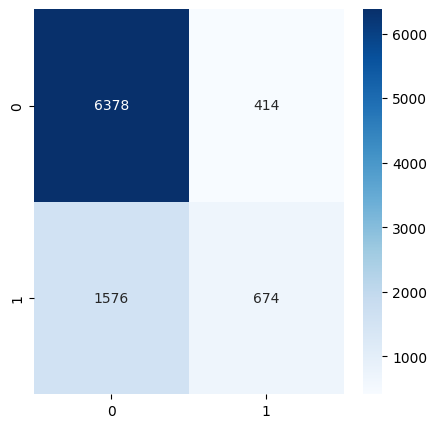

In [39]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

**Specificity** = TN / TN + FP

In [40]:
6378 / (6378 + 414)

0.9390459363957597

**Sensitivity** = TP / TP +FN

In [41]:
model.predict_proba(x_test)

array([[0.84821022, 0.15178978],
       [0.68112896, 0.31887104],
       [0.83046869, 0.16953131],
       ...,
       [0.786993  , 0.213007  ],
       [0.27848301, 0.72151699],
       [0.8474852 , 0.1525148 ]])

In [42]:
from sklearn.metrics import precision_score

In [43]:
precision_score(y_test, y_pred, pos_label=0)

0.8018606990193613

In [44]:
classification_report(y_test, y_pred, output_dict=True)

{'0': {'precision': 0.8018606990193613,
  'recall': 0.9390459363957597,
  'f1-score': 0.8650481486504815,
  'support': 6792.0},
 '1': {'precision': 0.6194852941176471,
  'recall': 0.2995555555555556,
  'f1-score': 0.4038346315158778,
  'support': 2250.0},
 'accuracy': 0.7799159477991595,
 'macro avg': {'precision': 0.7106729965685041,
  'recall': 0.6193007459756577,
  'f1-score': 0.6344413900831797,
  'support': 9042.0},
 'weighted avg': {'precision': 0.7564786307790541,
  'recall': 0.7799159477991595,
  'f1-score': 0.7502803524159252,
  'support': 9042.0}}

In [61]:
df_cw = pd.read_excel('CreditWorthiness.xlsx', sheet_name='Data', engine='openpyxl')

In [65]:
df_cw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Cbal         1000 non-null   object
 1   Cdur         1000 non-null   int64 
 2   Chist        1000 non-null   object
 3   Cpur         1000 non-null   object
 4   Camt         1000 non-null   int64 
 5   Sbal         1000 non-null   object
 6   Edur         1000 non-null   object
 7   InRate       1000 non-null   int64 
 8   MSG          1000 non-null   object
 9   Oparties     1000 non-null   object
 10  Rdur         1000 non-null   object
 11  Prop         1000 non-null   object
 12  age          1000 non-null   int64 
 13  inPlans      1000 non-null   object
 14  Htype        1000 non-null   object
 15  NumCred      1000 non-null   int64 
 16  JobType      1000 non-null   object
 17  Ndepend      1000 non-null   int64 
 18  telephone    1000 non-null   object
 19  foreign      1000 non-null  

In [67]:
df_cw.sample()

,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,InRate,MSG,Oparties,...,Prop,age,inPlans,Htype,NumCred,JobType,Ndepend,telephone,foreign,creditScore
900,no checking account,6,dues not paid earlier,electronics,17280,Rs. < 1000,more than 7 years,2,married or widowed male,no one,...,real estate,30,none,pays rent,2,employee with official position,1,no,no,good


In [68]:
htype_prob = df_cw['Htype'].value_counts(normalize=True)

In [70]:
-1 * np.sum(np.log2(htype_prob) * htype_prob)

np.float64(1.1390117663236383)

In [74]:
len(pd.get_dummies(df_cw).columns)

65

In [75]:
df_cw.columns

Index(['Cbal', 'Cdur', 'Chist', 'Cpur', 'Camt', 'Sbal', 'Edur', 'InRate',
       'MSG', 'Oparties', 'Rdur', 'Prop', 'age', 'inPlans', 'Htype', 'NumCred',
       'JobType', 'Ndepend', 'telephone', 'foreign', 'creditScore'],
      dtype='object')

In [ ]:
# How many records present with the following conditions
# age >= 25 and age <= 50,
# and inplans equals ‘bank’
# and Cpur is either ‘Business’ or ‘electronics’
# and foreign as ‘yes’?

In [85]:
df_cw[(df_cw['age'] >= 25) & (df_cw['age']<=50)
& (df_cw['inPlans'] == 'bank') & ((df_cw['Cpur'] == 'Business') | (df_cw['Cpur'] == 'electronics')) &
 (df_cw['foreign'] == 'yes')].shape

(0, 21)

In [88]:
cm = np.array([[300,200],[100,400]])


In [ ]:
# recall 3/5 = > TP / (TP + FN)
# precision 3/4 => TP / (TP + FP)
# F1 = 2 * (precision * recall / (precision + recall))
# F1 = 2 * ((3/5) * (3/4) / (3/5+3/4))

In [89]:
2 * ((3/5) * (3/4) / (3/5+3/4))

0.6666666666666665